# Fully Equivariant Hybrid: D4-CNN + Equivariant Bridge + p4m EquivQCNN (higher-capacity bridge)

This notebook implements a **fully `p4m` (D4: 90 rotations + mirror reflections) equivariant** hybrid
classical-quantum classifier, where **every learnable stage respects the symmetry**:

1. **D4 Steerable CNN** (`e2cnn`, `FlipRot2dOnR2(N=4)`) - rotation+reflection-equivariant feature extraction. **No `GroupPooling`** so the group structure is preserved.
2. **Equivariant bridge** (`e2cnn` 1x1 `R2Conv` on D4 regular fields) - **3 wide layers (`hidden_mult=(256, 128, 32)`)** that add capacity in a symmetry-preserving (weight-tied) way (comparable in size to the original dense bridge), then reduce to the quantum input while keeping equivariance.
3. **p4m EquivQCNN** built *exactly* as in Chang et al., *Approximately Equivariant Quantum Neural Network for p4m Group Symmetries in Images* ([arXiv:2310.02323](https://arxiv.org/abs/2310.02323)):
   - **Coordinate-Aware Amplitude (CAA) embedding** - x-register `q[0:n]`, y-register `q[n:2n]`.
   - Induced p4m representations `V_x = X_{0:n}`, `V_y = X_{n:2n}`, `V_r = V_x . prod SWAP(i, i+n)`.
   - **Twirled equivariant filters** `U2` (generators `{Y_iY_j, Z_iZ_j}`) and `U4` (generators `P_s P_s P_s' P_s'` linking the two registers).
   - **Configurable depth** `N_QLAYERS`: stacks `N_QLAYERS` equivariant (U2 -> U4) blocks, each with its own weight-tied param set, to add quantum capacity while staying p4m-equivariant.
   - **Approximately-invariant measurement** - `Rz(phi) + H` on paired `q_{i}` / `q_{i+n}`, probabilities summed.
4. **Invariant readout** -> class logits.

> The quantum block follows the paper's construction so it is **provably p4m-equivariant** (it commutes with `V_x, V_y, V_r`), unlike a generic angle-encoded QCNN.

In [1]:
import time
import os
import copy
import json
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn.functional as F

import torchquantum as tq
import numpy as np

from e2cnn import gspaces
from e2cnn import nn as e2nn

import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import (roc_auc_score, confusion_matrix,
                             classification_report, roc_curve, auc, f1_score)
from sklearn.preprocessing import label_binarize
import seaborn as sns

torch.manual_seed(42)
np.random.seed(42)

os.environ["OMP_NUM_THREADS"] = "1"

print(f"TorchQuantum version: {tq.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

TorchQuantum version: 0.1.8
PyTorch version: 2.5.1+cu124
CUDA available: True


In [2]:
from pathlib import Path
import importlib.util
import subprocess
import sys
import tarfile

CLASS_DIRS = {"axion", "cdm", "no_sub"}

def has_class_folders(root):
    root = Path(root)
    if not root.is_dir():
        return False
    present = {item.name for item in root.iterdir() if item.is_dir()}
    return CLASS_DIRS.issubset(present)

def ensure_gdown():
    if importlib.util.find_spec("gdown") is None:
        print("Installing gdown...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gdown"])
    import gdown
    return gdown

def show_dataset_folder(extract_dir):
    print()
    print("Files in dataset folder:")
    for item in sorted(extract_dir.iterdir()):
        print(item.name)

# Google Drive training dataset file
file_id = "11FVLA4IQgeRXx7Dpem14ayb_JCUD0pxX"
url = f"https://drive.google.com/uc?id={file_id}"

base_dir = Path("/home/jovyan/ssh-test-datavol-1")
extract_dir = base_dir / "dataset"
archive_path = base_dir / "data.tar.gz"
required_roots = [extract_dir / "Model_I"]

base_dir.mkdir(parents=True, exist_ok=True)
extract_dir.mkdir(parents=True, exist_ok=True)

if all(has_class_folders(root) for root in required_roots):
    print("Training dataset already extracted. Skipping gdown install, download, and extraction.")
    for root in required_roots:
        print("Found:", root)
else:
    if archive_path.exists() and archive_path.stat().st_size > 0:
        print("Using existing downloaded archive:", archive_path)
    else:
        if archive_path.exists():
            archive_path.unlink()
            print("Deleted empty/partial archive:", archive_path)
        print("Downloading training dataset...")
        gdown = ensure_gdown()
        gdown.download(url, str(archive_path), quiet=False)

    print("Archive path:", archive_path)
    print("File size GB:", round(archive_path.stat().st_size / 1024**3, 3))
    print("Extracting into:", extract_dir)
    with tarfile.open(archive_path, "r:gz") as tar:
        tar.extractall(extract_dir)

    print("Extracted to:", extract_dir)
    archive_path.unlink()
    print("Deleted downloaded archive:", archive_path)

    missing = [root for root in required_roots if not has_class_folders(root)]
    if missing:
        raise FileNotFoundError(f"Expected class folders not found after extraction: {missing}")

show_dataset_folder(extract_dir)


Training dataset already extracted. Skipping gdown install, download, and extraction.
Found: /home/jovyan/ssh-test-datavol-1/dataset/Model_I

Files in dataset folder:
Model_I
Model_I_test


In [3]:
from pathlib import Path
import importlib.util
import subprocess
import sys
import tarfile

CLASS_DIRS = {"axion", "cdm", "no_sub"}

def has_class_folders(root):
    root = Path(root)
    if not root.is_dir():
        return False
    present = {item.name for item in root.iterdir() if item.is_dir()}
    return CLASS_DIRS.issubset(present)

def ensure_gdown():
    if importlib.util.find_spec("gdown") is None:
        print("Installing gdown...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gdown"])
    import gdown
    return gdown

def show_dataset_folder(extract_dir):
    print()
    print("Files in dataset folder:")
    for item in sorted(extract_dir.iterdir()):
        print(item.name)

# Google Drive test dataset file
file_id = "1Y_q5ene_s0SML3TjRw6sjh8E_SQJD8zU"
url = f"https://drive.google.com/uc?id={file_id}"

base_dir = Path("/home/jovyan/ssh-test-datavol-1")
extract_dir = base_dir / "dataset"
archive_path = base_dir / "testdata.tar.gz"
required_roots = [extract_dir / "Model_I_test"]

base_dir.mkdir(parents=True, exist_ok=True)
extract_dir.mkdir(parents=True, exist_ok=True)

if all(has_class_folders(root) for root in required_roots):
    print("Test dataset already extracted. Skipping gdown install, download, and extraction.")
    for root in required_roots:
        print("Found:", root)
else:
    if archive_path.exists() and archive_path.stat().st_size > 0:
        print("Using existing downloaded archive:", archive_path)
    else:
        if archive_path.exists():
            archive_path.unlink()
            print("Deleted empty/partial archive:", archive_path)
        print("Downloading test dataset...")
        gdown = ensure_gdown()
        gdown.download(url, str(archive_path), quiet=False)

    print("Archive path:", archive_path)
    print("File size GB:", round(archive_path.stat().st_size / 1024**3, 3))
    print("Extracting into:", extract_dir)
    print("This may take time...")
    with tarfile.open(archive_path, "r:gz") as tar:
        tar.extractall(extract_dir)

    print("Extracted to:", extract_dir)
    archive_path.unlink()
    print("Deleted downloaded archive:", archive_path)

    missing = [root for root in required_roots if not has_class_folders(root)]
    if missing:
        raise FileNotFoundError(f"Expected class folders not found after extraction: {missing}")

show_dataset_folder(extract_dir)


Test dataset already extracted. Skipping gdown install, download, and extraction.
Found: /home/jovyan/ssh-test-datavol-1/dataset/Model_I_test

Files in dataset folder:
Model_I
Model_I_test


In [4]:
# ---- Quantum config ----
# CAA embedding needs 2n qubits: n for x-coordinate register, n for y-coordinate register.
n_coord = 4              # qubits per coordinate register
n_qubits = 2 * n_coord   # total qubits (= 8)

# ---- Training ----
step = 0.001
batch_size = 64
weight_decay = 1e-5
num_epochs = 50
patience = 12
WARMUP_EPOCHS = 5

# ---- Model ----
img_size = 150
in_channels = 1
num_classes = 3
DROPOUT_RATE = 0.3
USE_TRAINABLE_PHI = True   # M2 measurement (trainable phi); False = M1 (phi=0, stricter invariance)
N_QLAYERS = 4              # number of stacked equivariant QCNN conv blocks (depth -> more quantum params)

# Data paths - UPDATE THESE
NOTEBOOK_NAME = "fully_equivariant_p4m_qcnn_v2"
# Change this string to model_1/model_2/model_3/model_4 when changing data paths.
DATASET_ID = "model_1"
DATASET_ID = os.environ.get("DEEPLENSE_DATASET_ID", DATASET_ID)

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()
    for path in (start, *start.parents):
        if (path / "README.md").exists() and (path / "notebooks").exists():
            return path
    return start

def slugify(value):
    value = str(value).strip().lower()
    slug = "".join(ch if ch.isalnum() else "_" for ch in value)
    slug = "_".join(part for part in slug.split("_") if part)
    return slug or "model_1"

DATASET_ID = slugify(DATASET_ID)
VALID_DATASET_IDS = {f"model_{i}" for i in range(1, 5)}
if DATASET_ID not in VALID_DATASET_IDS:
    raise ValueError(f"DATASET_ID must be one of {sorted(VALID_DATASET_IDS)}, got {DATASET_ID!r}")

DATASET_ROOTS = {
    "model_1": "/home/jovyan/ssh-test-datavol-1/dataset/Model_I",
    "model_2": "/home/jovyan/ssh-test-datavol-1/dataset/Model_II",
    "model_3": "/home/jovyan/ssh-test-datavol-1/dataset/Model_III",
    "model_4": "/home/jovyan/ssh-test-datavol-1/dataset/Model_IV",
}
TEST_ROOTS = {
    "model_1": "/home/jovyan/ssh-test-datavol-1/dataset/Model_I_test",
    "model_2": "/home/jovyan/ssh-test-datavol-1/dataset/Model_II_test",
    "model_3": "/home/jovyan/ssh-test-datavol-1/dataset/Model_III_test",
    "model_4": "/home/jovyan/ssh-test-datavol-1/dataset/Model_IV_test",
}
DATA_ROOT = os.environ.get("DEEPLENSE_DATA_ROOT", DATASET_ROOTS[DATASET_ID])
TEST_DIR = os.environ.get("DEEPLENSE_TEST_DIR", TEST_ROOTS[DATASET_ID])
VAL_SPLIT = float(os.environ.get("DEEPLENSE_VAL_SPLIT", "0.20"))
if not 0.0 < VAL_SPLIT < 1.0:
    raise ValueError(f"VAL_SPLIT must be between 0 and 1, got {VAL_SPLIT}")

# DataLoader performance knobs. This mirrors the faster equiqnn notebook and avoids
# pre-caching the full dataset on the GPU before training starts.
CACHE_DATA_IN_MEMORY = os.environ.get("DEEPLENSE_CACHE_DATA", "1") != "0"
NUM_WORKERS = int(os.environ.get("DEEPLENSE_NUM_WORKERS", str(min(4, os.cpu_count() or 0))))
PREFETCH_FACTOR = int(os.environ.get("DEEPLENSE_PREFETCH_FACTOR", "4"))
PIN_MEMORY = torch.cuda.is_available()

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass

PROJECT_ROOT = find_project_root()
CLASSIFICATION_RUN_DIR = PROJECT_ROOT / "notebooks" / "equivariant" / NOTEBOOK_NAME / DATASET_ID
RESULTS_DIR = CLASSIFICATION_RUN_DIR / "results"
CHECKPOINT_DIR = CLASSIFICATION_RUN_DIR / "checkpoints"
CHECKPOINT_PATH = CHECKPOINT_DIR / f"best_{NOTEBOOK_NAME}_{DATASET_ID}.pth"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RUN_METADATA_PATH = CLASSIFICATION_RUN_DIR / "run_metadata.json"
with RUN_METADATA_PATH.open("w") as f:
    json.dump({
        "notebook_name": NOTEBOOK_NAME,
        "dataset_id": DATASET_ID,
        "data_root": str(DATA_ROOT),
        "test_dir": str(TEST_DIR),
        "val_split": VAL_SPLIT,
        "run_dir": str(CLASSIFICATION_RUN_DIR),
        "results_dir": str(RESULTS_DIR),
        "checkpoint_path": str(CHECKPOINT_PATH),
    }, f, indent=2)

print(f"DATA_ROOT: {DATA_ROOT}")
print(f"TEST_DIR:  {TEST_DIR}")
print(f"VAL_SPLIT: {VAL_SPLIT:.2f}")
print(f"Dataset/run id: {DATASET_ID}")
print(f"Run directory: {CLASSIFICATION_RUN_DIR}")
print(f"Results directory: {RESULTS_DIR}")
print(f"Checkpoint path: {CHECKPOINT_PATH}")
print(f"Run metadata: {RUN_METADATA_PATH}")

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Dataset/run id: {DATASET_ID}")
print(f"Run directory: {CLASSIFICATION_RUN_DIR}")
print(f"Results directory: {RESULTS_DIR}")
print(f"Checkpoint path: {CHECKPOINT_PATH}")
print(f"Run metadata: {RUN_METADATA_PATH}")
print(f"Architecture: Fully p4m-Equivariant Hybrid (D4-CNN + Equiv-Bridge + paper EquivQCNN)")
print(f"Quantum: {n_qubits} qubits (CAA: {n_coord}+{n_coord})")
print(f"Image size: {img_size}x{img_size}, Classes: {num_classes}")
print(f"Device: {device}")
print(f"Cache in RAM: {CACHE_DATA_IN_MEMORY}")
print(f"DataLoader workers: {NUM_WORKERS}, prefetch_factor={PREFETCH_FACTOR}, pin_memory={PIN_MEMORY}")


DATA_ROOT: /home/jovyan/ssh-test-datavol-1/dataset/Model_I
TEST_DIR:  /home/jovyan/ssh-test-datavol-1/dataset/Model_I_test
VAL_SPLIT: 0.20
Dataset/run id: model_1
Run directory: /home/jovyan/ssh-test-datavol-1/deeplense-quantum/notebooks/equivariant/fully_equivariant_p4m_qcnn_v2/model_1
Results directory: /home/jovyan/ssh-test-datavol-1/deeplense-quantum/notebooks/equivariant/fully_equivariant_p4m_qcnn_v2/model_1/results
Checkpoint path: /home/jovyan/ssh-test-datavol-1/deeplense-quantum/notebooks/equivariant/fully_equivariant_p4m_qcnn_v2/model_1/checkpoints/best_fully_equivariant_p4m_qcnn_v2_model_1.pth
Run metadata: /home/jovyan/ssh-test-datavol-1/deeplense-quantum/notebooks/equivariant/fully_equivariant_p4m_qcnn_v2/model_1/run_metadata.json
Dataset/run id: model_1
Run directory: /home/jovyan/ssh-test-datavol-1/deeplense-quantum/notebooks/equivariant/fully_equivariant_p4m_qcnn_v2/model_1
Results directory: /home/jovyan/ssh-test-datavol-1/deeplense-quantum/notebooks/equivariant/fully_e

In [5]:
from typing import Dict, Any, List, Tuple, Optional
import collections


IMAGE_KEYS = ("image", "img", "x", "data", "array", "arr", "lens", "sample")


def extract_image_array(value):
    """Return the image array from raw .npy content, including object arrays."""
    if isinstance(value, np.ndarray):
        if value.dtype == object:
            if value.ndim == 0:
                return extract_image_array(value.item())
            for item in value.reshape(-1):
                try:
                    candidate = extract_image_array(item)
                    if np.asarray(candidate).ndim >= 2:
                        return candidate
                except Exception:
                    continue
            return np.asarray(value.tolist())
        return value

    if isinstance(value, dict):
        for key in IMAGE_KEYS:
            if key in value:
                return extract_image_array(value[key])
        for item in value.values():
            try:
                candidate = extract_image_array(item)
                if np.asarray(candidate).ndim >= 2:
                    return candidate
            except Exception:
                continue
        raise ValueError("Could not find an image-like array in .npy dict")

    if isinstance(value, (list, tuple)):
        for item in value:
            try:
                candidate = extract_image_array(item)
                if np.asarray(candidate).ndim >= 2:
                    return candidate
            except Exception:
                continue
        return np.asarray(value)

    return np.asarray(value)


def load_npy_image(filepath):
    raw = np.load(filepath, allow_pickle=True)
    arr = np.asarray(extract_image_array(raw))
    if arr.dtype == object:
        arr = np.asarray(extract_image_array(arr), dtype=np.float32)
    else:
        arr = arr.astype(np.float32, copy=False)

    arr = np.squeeze(arr)
    if arr.ndim == 2:
        arr = arr[np.newaxis, :, :]
    elif arr.ndim == 3:
        if arr.shape[0] not in (1, 3):
            arr = arr.transpose(2, 0, 1)
    else:
        raise ValueError(f"Expected a 2D or 3D image array from {filepath}, got shape {arr.shape}")

    if arr.size == 0:
        raise ValueError(f"Empty image array in {filepath}")

    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    arr_max = float(np.max(arr))
    if arr_max > 1.0:
        arr = arr / arr_max
    return arr.astype(np.float32, copy=False)


class NPYImageFolder(Dataset):
    """Dataset loader for .npy image files organized in class folders."""

    def __init__(self, root_dir, transform=None, samples=None, classes=None, class_to_idx=None, cache=False):
        self.root_dir = str(root_dir)
        self.transform = transform
        self.cache = None
        if not os.path.isdir(self.root_dir):
            raise FileNotFoundError(f"Dataset directory not found: {self.root_dir}")

        self.classes = list(classes) if classes is not None else sorted(
            d for d in os.listdir(self.root_dir)
            if os.path.isdir(os.path.join(self.root_dir, d))
        )
        self.class_to_idx = dict(class_to_idx) if class_to_idx is not None else {
            cls: idx for idx, cls in enumerate(self.classes)
        }

        if samples is None:
            self.samples = []
            for class_name in self.classes:
                class_dir = os.path.join(self.root_dir, class_name)
                for filename in sorted(os.listdir(class_dir)):
                    if filename.endswith(".npy"):
                        filepath = os.path.join(class_dir, filename)
                        self.samples.append((filepath, self.class_to_idx[class_name]))
        else:
            self.samples = list(samples)

        if not self.samples:
            raise RuntimeError(f"No .npy files found under {self.root_dir}")

        self.labels = torch.tensor([label for _, label in self.samples], dtype=torch.long)

        print(f"Found {len(self.samples)} samples in {self.root_dir}")
        print(f"Classes: {self.classes}")

        if cache:
            desc = f"cache {Path(self.root_dir).name}"
            print(f"Caching {len(self.samples)} decoded samples from {self.root_dir} in RAM...")
            self.cache = [
                torch.from_numpy(np.ascontiguousarray(load_npy_image(filepath))).float()
                for filepath, _ in tqdm(self.samples, desc=desc, leave=False)
            ]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        filepath, label = self.samples[idx]
        if self.cache is None:
            arr = load_npy_image(filepath)
            tensor = torch.from_numpy(np.ascontiguousarray(arr)).float()
        else:
            tensor = self.cache[idx]

        if self.transform:
            tensor = self.transform(tensor)

        return tensor, label


class NPYTransform:
    """Resize and channel-match NPY tensors for the fully equivariant grayscale model."""

    def __init__(self, img_size, in_channels=1):
        self.img_size = img_size
        self.in_channels = in_channels

    def __call__(self, x):
        if x.shape[0] == 1 and self.in_channels == 3:
            x = x.repeat(3, 1, 1)
        elif x.shape[0] == 3 and self.in_channels == 1:
            x = x.mean(dim=0, keepdim=True)
        elif x.shape[0] != self.in_channels:
            x = x[:self.in_channels]

        if x.shape[-1] != self.img_size or x.shape[-2] != self.img_size:
            x = F.interpolate(
                x.unsqueeze(0), size=(self.img_size, self.img_size),
                mode="bilinear", align_corners=False,
            ).squeeze(0)
        return x


class GPUAugment(nn.Module):
    """On-the-fly D4 augmentation on the current training batch."""

    def __init__(self, p_hflip: float = 0.5, p_vflip: float = 0.5, p_rot90: float = 0.75):
        super().__init__()
        self.p_hflip = p_hflip
        self.p_vflip = p_vflip
        self.p_rot90 = p_rot90

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        b = x.shape[0]
        dev = x.device
        m = (torch.rand(b, device=dev) < self.p_hflip).view(b, 1, 1, 1)
        x = torch.where(m, x.flip(-1), x)
        m = (torch.rand(b, device=dev) < self.p_vflip).view(b, 1, 1, 1)
        x = torch.where(m, x.flip(-2), x)
        if torch.rand(1, device=dev).item() < self.p_rot90:
            k = int(torch.randint(1, 4, (1,), device=dev).item())
            x = torch.rot90(x, k, dims=[-2, -1])
        return x


def stratified_train_val_samples(samples, val_split=0.20, seed=42):
    """Split a single class-folder dataset into train/val while preserving each class."""
    labels = np.array([label for _, label in samples])
    rng = np.random.default_rng(seed)
    train_indices, val_indices = [], []

    for class_id in sorted(np.unique(labels).tolist()):
        class_indices = np.where(labels == class_id)[0]
        rng.shuffle(class_indices)
        if len(class_indices) <= 1:
            n_val = 0
        else:
            n_val = max(1, int(round(len(class_indices) * val_split)))
            n_val = min(n_val, len(class_indices) - 1)
        val_indices.extend(class_indices[:n_val].tolist())
        train_indices.extend(class_indices[n_val:].tolist())

    rng.shuffle(train_indices)
    rng.shuffle(val_indices)
    train_samples = [samples[i] for i in train_indices]
    val_samples = [samples[i] for i in val_indices]
    if not train_samples or not val_samples:
        raise ValueError("Train/val split is empty. Check VAL_SPLIT and per-class sample counts.")
    return train_samples, val_samples


def make_dataloader(dataset, batch_size, shuffle):
    kwargs = {
        "batch_size": batch_size,
        "shuffle": shuffle,
        "num_workers": NUM_WORKERS,
        "pin_memory": PIN_MEMORY,
    }
    if NUM_WORKERS > 0:
        kwargs["persistent_workers"] = True
        kwargs["prefetch_factor"] = PREFETCH_FACTOR
    return DataLoader(dataset, **kwargs)


def build_gpu_loaders(data_root, test_dir, img_size, batch_size, in_channels,
                      dev, val_split=0.20, seed=42, use_augmentation=True):
    """Build train/val/test loaders without pre-caching the full dataset on the GPU."""
    t0 = time.time()
    transform = NPYTransform(img_size, in_channels=in_channels)
    cache_data = CACHE_DATA_IN_MEMORY

    full_dataset = NPYImageFolder(data_root, transform=None, cache=False)
    train_samples, val_samples = stratified_train_val_samples(
        full_dataset.samples, val_split=val_split, seed=seed
    )
    train_set = NPYImageFolder(
        data_root, transform, samples=train_samples,
        classes=full_dataset.classes, class_to_idx=full_dataset.class_to_idx,
        cache=cache_data,
    )
    val_set = NPYImageFolder(
        data_root, transform, samples=val_samples,
        classes=full_dataset.classes, class_to_idx=full_dataset.class_to_idx,
        cache=cache_data,
    )
    test_set = NPYImageFolder(test_dir, transform, cache=cache_data)

    if test_set.classes != full_dataset.classes:
        raise ValueError(
            f"Class folders differ between DATA_ROOT and TEST_DIR: "
            f"{full_dataset.classes} vs {test_set.classes}"
        )

    train_loader = make_dataloader(train_set, batch_size=batch_size, shuffle=True)
    val_loader = make_dataloader(val_set, batch_size=batch_size, shuffle=False)
    test_loader = make_dataloader(test_set, batch_size=batch_size, shuffle=False)
    augmenter = GPUAugment().to(dev) if use_augmentation else None

    counts = collections.Counter(train_set.labels.tolist())
    print(f"Loader build took {time.time() - t0:.1f}s")
    print(f"Sizes: train={len(train_set)} val={len(val_set)} test={len(test_set)}")
    print("Class counts (train):", {full_dataset.classes[k]: v for k, v in sorted(counts.items())})
    print(f"Cache in RAM: {'ON' if cache_data else 'OFF'}")
    print(f"DataLoader workers: {NUM_WORKERS}, pin_memory={PIN_MEMORY}")
    print(f"GPUAugment: {'ON' if augmenter is not None else 'OFF'}")
    return train_loader, val_loader, test_loader, augmenter, full_dataset.classes


## 1. D4 (p4m) Steerable CNN feature extractor

Uses `gspaces.FlipRot2dOnR2(N=4)` (the full **D4 / p4m** group: 4 rotations x 2 flips = 8 elements).
Crucially we **remove `GroupPooling`** and instead reduce the spatial dimensions to `1x1`, returning a
stack of D4 **regular-representation** fields. Under any p4m transform of the input, these fields permute
by the (known) regular representation - i.e. the features stay *equivariant*, not collapsed to invariant.

In [6]:
class D4SteerableCNN_Features(nn.Module):
    """p4m (D4) steerable CNN. Returns regular-rep fields at 1x1 spatial size (still equivariant)."""

    def __init__(self, n_rotations=4):
        super().__init__()

        # Full dihedral group D4 = 90-deg rotations + reflections => p4m.
        self.r2_act = gspaces.FlipRot2dOnR2(N=n_rotations)

        in_type = e2nn.FieldType(self.r2_act, [self.r2_act.trivial_repr])
        self.input_type = in_type

        out_type = e2nn.FieldType(self.r2_act, 16 * [self.r2_act.regular_repr])
        self.block1 = e2nn.SequentialModule(
            e2nn.MaskModule(in_type, 150, margin=1),
            e2nn.R2Conv(in_type, out_type, kernel_size=7, padding=1, bias=False),
            e2nn.InnerBatchNorm(out_type),
            e2nn.ReLU(out_type, inplace=True)
        )

        in_type = self.block1.out_type
        out_type = e2nn.FieldType(self.r2_act, 24 * [self.r2_act.regular_repr])
        self.block2 = e2nn.SequentialModule(
            e2nn.R2Conv(in_type, out_type, kernel_size=5, padding=2, bias=False),
            e2nn.InnerBatchNorm(out_type),
            e2nn.ReLU(out_type, inplace=True)
        )
        self.pool1 = e2nn.PointwiseAvgPoolAntialiased(out_type, sigma=0.66, stride=2)

        in_type = self.block2.out_type
        out_type = e2nn.FieldType(self.r2_act, 24 * [self.r2_act.regular_repr])
        self.block3 = e2nn.SequentialModule(
            e2nn.R2Conv(in_type, out_type, kernel_size=5, padding=2, bias=False),
            e2nn.InnerBatchNorm(out_type),
            e2nn.ReLU(out_type, inplace=True)
        )

        in_type = self.block3.out_type
        out_type = e2nn.FieldType(self.r2_act, 48 * [self.r2_act.regular_repr])
        self.block4 = e2nn.SequentialModule(
            e2nn.R2Conv(in_type, out_type, kernel_size=5, padding=2, bias=False),
            e2nn.InnerBatchNorm(out_type),
            e2nn.ReLU(out_type, inplace=True)
        )
        self.pool2 = e2nn.PointwiseAvgPoolAntialiased(out_type, sigma=0.66, stride=2)

        in_type = self.block4.out_type
        out_type = e2nn.FieldType(self.r2_act, 48 * [self.r2_act.regular_repr])
        self.block5 = e2nn.SequentialModule(
            e2nn.R2Conv(in_type, out_type, kernel_size=5, padding=2, bias=False),
            e2nn.InnerBatchNorm(out_type),
            e2nn.ReLU(out_type, inplace=True)
        )
        self.pool3 = e2nn.PointwiseAvgPoolAntialiased(out_type, sigma=0.66, stride=2)

        in_type = self.block5.out_type
        out_type = e2nn.FieldType(self.r2_act, 64 * [self.r2_act.regular_repr])
        self.block6 = e2nn.SequentialModule(
            e2nn.R2Conv(in_type, out_type, kernel_size=3, padding=1, bias=False),
            e2nn.InnerBatchNorm(out_type),
            e2nn.ReLU(out_type, inplace=True)
        )

        # Collapse spatial dims to 1x1 while staying equivariant (group structure preserved).
        self.adaptive_pool = e2nn.PointwiseAdaptiveAvgPool(out_type, 1)
        self.out_type = out_type

    def forward(self, x):
        x = e2nn.GeometricTensor(x, self.input_type)
        x = self.block1(x)
        x = self.block2(x)
        x = self.pool1(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.pool2(x)
        x = self.block5(x)
        x = self.pool3(x)
        x = self.block6(x)
        x = self.adaptive_pool(x)   # -> GeometricTensor, spatial 1x1, regular-rep fields
        return x


## 2. Equivariant bridge

A bridge made entirely of `e2cnn` operations on D4 regular fields. Implemented as `1x1` `R2Conv`
layers (which **are** group-equivariant fully-connected maps on the 1x1 feature), with equivariant
norm/nonlinearity/dropout. The output is a **single D4 regular field = 8 scalars = 8 quantum inputs**,
so a p4m transform of the image induces the D4 regular-representation permutation of these 8 values.

In [7]:
class EquivariantMLPBridge(nn.Module):
    """Equivariant bridge: maps D4 regular fields -> one D4 regular field (8 values for the qubits).

    Higher-capacity version: 3 equivariant 1x1-conv layers with wider regular-rep hidden
    multipliers. Capacity is added in a SYMMETRY-PRESERVING way (weight-tied across the 8
    D4 group elements), so the bridge stays exactly p4m-equivariant while having many more
    trainable parameters than the lean (32, 8) variant.
    """

    def __init__(self, r2_act, in_type, hidden_mult=(256, 128, 32), dropout_rate=0.3):
        super().__init__()
        self.r2_act = r2_act

        t_in = in_type
        t_h1 = e2nn.FieldType(r2_act, hidden_mult[0] * [r2_act.regular_repr])
        t_h2 = e2nn.FieldType(r2_act, hidden_mult[1] * [r2_act.regular_repr])
        t_h3 = e2nn.FieldType(r2_act, hidden_mult[2] * [r2_act.regular_repr])
        # final: exactly ONE regular field -> |D4| = 8 scalar outputs (one per group element)
        t_out = e2nn.FieldType(r2_act, 1 * [r2_act.regular_repr])

        self.fc1 = e2nn.SequentialModule(
            e2nn.R2Conv(t_in, t_h1, kernel_size=1, bias=False),
            e2nn.InnerBatchNorm(t_h1),
            e2nn.ReLU(t_h1, inplace=True),
            e2nn.PointwiseDropout(t_h1, p=dropout_rate),
        )
        self.fc2 = e2nn.SequentialModule(
            e2nn.R2Conv(t_h1, t_h2, kernel_size=1, bias=False),
            e2nn.InnerBatchNorm(t_h2),
            e2nn.ReLU(t_h2, inplace=True),
            e2nn.PointwiseDropout(t_h2, p=dropout_rate * 0.8),
        )
        self.fc3 = e2nn.SequentialModule(
            e2nn.R2Conv(t_h2, t_h3, kernel_size=1, bias=False),
            e2nn.InnerBatchNorm(t_h3),
            e2nn.ReLU(t_h3, inplace=True),
            e2nn.PointwiseDropout(t_h3, p=dropout_rate * 0.6),
        )
        self.fc_out = e2nn.R2Conv(t_h3, t_out, kernel_size=1, bias=False)
        self.out_type = t_out

    def forward(self, x):
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.fc3(x)
        x = self.fc_out(x)            # GeometricTensor, 1 regular field, 1x1 spatial
        x = x.tensor                  # (B, 8, 1, 1)
        x = x.reshape(x.shape[0], -1) # (B, 8)
        return x


## 3. p4m EquivQCNN (faithful to arXiv:2310.02323)

**Coordinate-Aware Amplitude (CAA) embedding** splits the qubits into an x-register `q[0:n]` and a
y-register `q[n:2n]`. The induced p4m representations are then simple Pauli/SWAP operators:

- `V_x = X^{(x)}` (Pauli-X on every x-register qubit)
- `V_y = X^{(y)}` (Pauli-X on every y-register qubit)
- `V_r = V_x . prod_i SWAP(i, i+n)` (90-deg rotation)

**Equivariant filters via twirling** (must commute with `V_x, V_y, V_r`):

- Within a register, the 2-body equivariant generators are `{Y_iY_j, Z_iZ_j}` -> the `U2` filter is
  built from `IsingYY` + `IsingZZ` (+ no single-qubit X-only term needed for the scan phase).
- Linking the two registers requires an **even number of Y/Z on each register**, giving the 4-body
  `U4` filter from generators of the form `P_s P_s P_s' P_s'` (e.g. `ZZ . ZZ`, `YY . YY`).

**Approximately-invariant measurement**: apply `Rz(phi) + H` to the surviving paired qubits
`q_{i_m}` (x-register) and `q_{i_m+n}` (y-register), then sum their single-qubit `|0>/|1>`
probability distributions (averaged). `phi=0` => strict invariance (M1); trainable `phi` => M2.

In [8]:
class PaperEquivQCNN(tq.QuantumModule):
    """p4m-equivariant QCNN with CAA embedding, twirled U2/U4 filters, approx-invariant readout.

    Layout (n_coord = n): x-register = wires [0..n-1], y-register = wires [n..2n-1].
    Equivariant by construction: every gate commutes with V_x, V_y, V_r.
    """

    def __init__(self, n_coord=4, num_classes=3, use_trainable_phi=True, n_layers=2):
        super().__init__()
        self.n_coord = n_coord
        self.n_qubits = 2 * n_coord
        self.num_classes = num_classes
        self.use_trainable_phi = use_trainable_phi
        self.n_layers = n_layers

        # number of measured-qubit pairs needed to encode L classes: ceil(log2(L)) per register
        self.n_measure = max(1, int(np.ceil(np.log2(num_classes))))

        # ---- Trainable parameters ----
        # Each equivariant block = [ U2 scan (within-register) -> U4 link (cross-register) ].
        # We STACK `n_layers` such blocks. Every block has its OWN weight-shared param set
        # (params tied across all qubit pairs WITHIN the block => stays p4m-equivariant).
        # Per block: u2 (2 params) + u4 (2 params) = 4 trainable angles.
        self.u2_params = nn.ParameterList(
            [nn.Parameter(0.1 * torch.randn(2)) for _ in range(n_layers)]
        )
        self.u4_params = nn.ParameterList(
            [nn.Parameter(0.1 * torch.randn(2)) for _ in range(n_layers)]
        )

        # measurement mixing angle phi (M2 if trainable, else fixed 0 -> M1)
        if use_trainable_phi:
            self.phi = nn.Parameter(0.1 * torch.randn(self.n_measure))
        else:
            self.register_buffer("phi", torch.zeros(self.n_measure))

        self.measure = tq.MeasureAll(tq.PauliZ)

    # ---------- equivariant generator gates ----------
    def _ising_zz(self, qdev, theta, w0, w1):
        """exp(-i theta/2 Z Z) via CNOT-RZ-CNOT. Commutes with X X (=> equivariant)."""
        qdev.cnot(wires=[w0, w1])
        qdev.rz(wires=w1, params=theta)
        qdev.cnot(wires=[w0, w1])

    def _ising_yy(self, qdev, theta, w0, w1, pi2):
        """exp(-i theta/2 Y Y) via RX(+-pi/2) basis change + ZZ. Commutes with X X."""
        qdev.rx(wires=w0, params=pi2)
        qdev.rx(wires=w1, params=pi2)
        qdev.cnot(wires=[w0, w1])
        qdev.rz(wires=w1, params=theta)
        qdev.cnot(wires=[w0, w1])
        qdev.rx(wires=w0, params=-pi2)
        qdev.rx(wires=w1, params=-pi2)

    def _u2(self, qdev, p, w0, w1, pi2):
        """U2 filter = IsingZZ(theta0) . IsingYY(theta1). Equivariant within a register."""
        self._ising_zz(qdev, p[:, 0], w0, w1)
        self._ising_yy(qdev, p[:, 1], w0, w1, pi2)

    def _u4(self, qdev, p, wx0, wx1, wy0, wy1, pi2):
        """U4 4-body filter linking the two registers.
        Built from generators with an EVEN number of Y/Z on each register so it commutes
        with V_x = X^(x), V_y = X^(y) and (by symmetric wiring) with V_r.
        We use (Z_{x0}Z_{x1})(Z_{y0}Z_{y1}) and (Y..)(Y..) decomposed into Ising blocks.
        """
        # ZZ on x-pair, then ZZ on y-pair, sharing one angle (even # Z on each register)
        self._ising_zz(qdev, p[:, 0], wx0, wx1)
        self._ising_zz(qdev, p[:, 0], wy0, wy1)
        # YY on x-pair, then YY on y-pair, sharing one angle (even # Y on each register)
        self._ising_yy(qdev, p[:, 1], wx0, wx1, pi2)
        self._ising_yy(qdev, p[:, 1], wy0, wy1, pi2)

    def forward(self, q_in):
        bsz = q_in.shape[0]
        dev = q_in.device
        n = self.n_coord

        qdev = tq.QuantumDevice(n_wires=self.n_qubits, bsz=bsz, device=dev)
        pi2 = torch.full((bsz,), np.pi / 2, device=dev, dtype=q_in.dtype)

        def expand(par):
            return par.unsqueeze(0).expand(bsz, -1)

        # ---- CAA embedding: RY angle-load each coordinate qubit ----
        # (x-register encodes x-coordinate features, y-register encodes y-coordinate features)
        for i in range(self.n_qubits):
            qdev.ry(wires=i, params=q_in[:, i])

        # ---- Stacked equivariant conv blocks (depth = n_layers) ----
        # Each block reuses ONE shared U2 param set and ONE shared U4 param set, so adding
        # depth multiplies the trainable angle count while preserving p4m-equivariance
        # (weights stay tied across qubit pairs within every block).
        for layer in range(self.n_layers):
            c_u2 = expand(self.u2_params[layer])
            c_u4 = expand(self.u4_params[layer])

            # U2 scan within each register separately (shared params => respects V_r swap)
            for i in range(n - 1):
                self._u2(qdev, c_u2, i, i + 1, pi2)
            for i in range(n - 1):
                self._u2(qdev, c_u2, n + i, n + i + 1, pi2)

            # U4 link x-register <-> y-register (fully equivariant cross-register coupling)
            for i in range(0, n - 1, 2):
                self._u4(qdev, c_u4, i, i + 1, n + i, n + i + 1, pi2)

        # ---- Approximately-invariant measurement ----
        # Surviving measured qubits: q_{i_m} in x-register and q_{i_m + n} in y-register.
        # Apply Rz(phi)+H IN PLACE on the measured qubits, then read all-qubit <Z> once.
        # Averaging each measured x-qubit with its y-register partner makes the readout
        # invariant under the V_r register-swap (and approximately under V_x, V_y).
        for m in range(self.n_measure):
            phi_vec = self.phi[m].expand(bsz)
            for w in (m, n + m):
                qdev.rz(wires=w, params=phi_vec)
                qdev.h(wires=w)

        z_all = self.measure(qdev)            # (bsz, n_qubits) single-qubit <Z>

        logits = []
        for m in range(self.n_measure):
            # average measured x-qubit with its paired y-qubit -> V_r-invariant
            logits.append(0.5 * (z_all[:, m] + z_all[:, n + m]))
        out = torch.stack(logits, dim=1)      # (bsz, n_measure)
        return out


## 4. Full hybrid model + invariant readout

In [9]:
class FullyEquivariantHybrid(nn.Module):
    """D4 steerable CNN -> equivariant bridge -> paper p4m EquivQCNN -> invariant logits."""

    def __init__(self, in_channels=1, n_coord=4, num_classes=3,
                 dropout_rate=0.3, n_rotations=4, img_size=150,
                 use_trainable_phi=True, n_qlayers=2):
        super().__init__()
        self.n_coord = n_coord
        self.n_qubits = 2 * n_coord

        # 1) D4 (p4m) steerable CNN
        self.ecnn = D4SteerableCNN_Features(n_rotations=n_rotations)

        # 2) Equivariant bridge -> one D4 regular field (= 8 = n_qubits scalars)
        self.bridge = EquivariantMLPBridge(
            self.ecnn.r2_act, self.ecnn.out_type,
            hidden_mult=(256, 128, 32), dropout_rate=dropout_rate
        )
        assert self.bridge.out_type.size == self.n_qubits, (
            f"bridge outputs {self.bridge.out_type.size}, expected {self.n_qubits}")

        # 3) p4m EquivQCNN (paper construction); n_qlayers stacks equivariant conv blocks
        self.qcnn = PaperEquivQCNN(
            n_coord=n_coord, num_classes=num_classes,
            use_trainable_phi=use_trainable_phi, n_layers=n_qlayers
        )

        # 4) Invariant readout: map measured (n_measure) values -> class logits.
        # Linear-only (no nonlinearity that would break the carefully-built invariance budget).
        self.readout = nn.Linear(self.qcnn.n_measure, num_classes)

    def forward(self, x):
        feats = self.ecnn(x)                  # GeometricTensor (equivariant)
        bridge_out = self.bridge(feats)       # (B, 8) - transforms by D4 regular rep
        q_in = torch.tanh(bridge_out) * (np.pi / 2)
        q_out = self.qcnn(q_in)               # (B, n_measure) - approx invariant
        return self.readout(q_out)

    def count_parameters(self):
        total = sum(p.numel() for p in self.parameters() if p.requires_grad)
        ecnn_p = sum(p.numel() for p in self.ecnn.parameters() if p.requires_grad)
        bridge_p = sum(p.numel() for p in self.bridge.parameters() if p.requires_grad)
        q_p = sum(p.numel() for p in self.qcnn.parameters() if p.requires_grad)
        post_p = sum(p.numel() for p in self.readout.parameters() if p.requires_grad)
        return {'total': total, 'ecnn': ecnn_p, 'bridge': bridge_p,
                'quantum': q_p, 'readout': post_p}


## 5. Equivariance sanity check

Quick numerical test that the **quantum block is p4m-equivariant**: feeding `V_x`/`V_y`/`V_r`-transformed
inputs should leave the (approximately) invariant measurement unchanged. We emulate the induced
representations on the 8 CAA inputs (X-flips = sign behaviour, register SWAP for rotation).

In [10]:
@torch.no_grad()
def check_qcnn_invariance(n_coord=4, num_classes=3, use_trainable_phi=False, n_layers=2, tol=1e-4):
    """Test the QCNN readout invariance under V_r (register swap) of the CAA inputs."""
    q = PaperEquivQCNN(n_coord=n_coord, num_classes=num_classes,
                       use_trainable_phi=use_trainable_phi, n_layers=n_layers)
    q.eval()
    n = n_coord
    x = torch.randn(4, 2 * n)

    base = q(x)

    # V_r induced on CAA inputs: swap x-register <-> y-register coordinate values
    x_rot = x.clone()
    x_rot[:, :n], x_rot[:, n:] = x[:, n:].clone(), x[:, :n].clone()
    rot = q(x_rot)

    diff = (base - rot).abs().max().item()
    print(f"max |y(x) - y(V_r x)| = {diff:.2e}  (should be ~0 for register-swap invariance)")
    print("V_r-invariant readout:", diff < 1e-3)
    return diff


_ = check_qcnn_invariance(n_coord=n_coord, num_classes=num_classes,
                          use_trainable_phi=False, n_layers=N_QLAYERS)


max |y(x) - y(V_r x)| = 2.98e-07  (should be ~0 for register-swap invariance)
V_r-invariant readout: True


In [11]:
def warmup_cosine_lambda(epoch, warmup_epochs, total_epochs):
    if epoch < warmup_epochs:
        return (epoch + 1) / warmup_epochs
    progress = (epoch - warmup_epochs) / max(1, total_epochs - warmup_epochs)
    return 0.5 * (1.0 + np.cos(np.pi * progress))


def train_model(model, criterion, optimizer, scheduler, dataloaders,
                dataset_sizes, num_epochs, patience=20, device='cuda', augmenter=None):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    best_loss = float('inf')
    epochs_no_improve = 0

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    print("Training started:")
    print(f"  Early stopping patience: {patience} epochs")
    print(f"  Warmup epochs: {WARMUP_EPOCHS}")

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 35)

        for phase in ["train", "validation"]:
            if phase == "train":
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            pbar = tqdm(dataloaders[phase], desc=f"{phase}")
            for inputs, labels in pbar:
                inputs = inputs.to(device, non_blocking=PIN_MEMORY)
                labels = labels.to(device, non_blocking=PIN_MEMORY)

                if phase == "train" and augmenter is not None:
                    inputs = augmenter(inputs)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == "train":
                        loss.backward()
                        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                pbar.set_postfix({'loss': f'{loss.item():.4f}'})

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            if phase == "train":
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
                scheduler.step()
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())

                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                    epochs_no_improve = 0
                    print(f"  >>> New best model! (val_acc={best_acc:.4f})")
                else:
                    epochs_no_improve += 1

                if epoch_loss < best_loss:
                    best_loss = epoch_loss

        if epochs_no_improve >= patience:
            print(f"\nEarly stopping triggered after {epoch+1} epochs")
            break

    time_elapsed = time.time() - since
    print(f"\nTraining completed in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
    print(f"Best val Acc: {best_acc:.4f}")

    model.load_state_dict(best_model_wts)
    return model, history


@torch.no_grad()
def evaluate_model(model, test_loader, device='cuda'):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    for inputs, labels in tqdm(test_loader, desc="Testing"):
        inputs = inputs.to(device, non_blocking=PIN_MEMORY)
        labels = labels.to(device, non_blocking=PIN_MEMORY)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    try:
        roc_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
    except Exception:
        roc_auc = 0.0

    return accuracy, all_preds, all_labels, all_probs, roc_auc


In [12]:
def plot_training_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history['train_loss'], label='Train', linewidth=2)
    axes[0].plot(history['val_loss'], label='Validation', linewidth=2)
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss Curve', fontweight='bold'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].plot(history['train_acc'], label='Train', linewidth=2)
    axes[1].plot(history['val_acc'], label='Validation', linewidth=2)
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Accuracy Curve', fontweight='bold'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.suptitle('Fully p4m-Equivariant Hybrid - Training Curves', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'training_curves_fully_equiv.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_confusion_matrix(test_labels, test_preds, class_names, test_acc):
    cm = confusion_matrix(test_labels, test_preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True'); axes[0].set_title('Counts')
    sns.heatmap(cm_norm, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[1])
    axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True'); axes[1].set_title('Percent')
    plt.suptitle(f'Test Accuracy: {test_acc*100:.2f}%', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'confusion_matrix_fully_equiv.png', dpi=150, bbox_inches='tight')
    plt.show()
    return cm


In [13]:
train_loader, val_loader, test_loader, augmenter, class_names = build_gpu_loaders(
    DATA_ROOT, TEST_DIR, img_size, batch_size, in_channels, device,
    val_split=VAL_SPLIT, seed=42, use_augmentation=True,
)

dataset_sizes = {
    "train": len(train_loader.dataset),
    "validation": len(val_loader.dataset)
}
dataloaders = {
    "train": train_loader,
    "validation": val_loader
}

print(f"\nDataset sizes: Train={dataset_sizes['train']}, "
      f"Val={dataset_sizes['validation']}, Test={len(test_loader.dataset)}")
print(f"Classes: {class_names}")


Found 87525 samples in /home/jovyan/ssh-test-datavol-1/dataset/Model_I
Classes: ['axion', 'cdm', 'no_sub']
Found 70021 samples in /home/jovyan/ssh-test-datavol-1/dataset/Model_I
Classes: ['axion', 'cdm', 'no_sub']
Caching 70021 decoded samples from /home/jovyan/ssh-test-datavol-1/dataset/Model_I in RAM...


Found 17504 samples in /home/jovyan/ssh-test-datavol-1/dataset/Model_I
Classes: ['axion', 'cdm', 'no_sub']
Caching 17504 decoded samples from /home/jovyan/ssh-test-datavol-1/dataset/Model_I in RAM...


Found 15000 samples in /home/jovyan/ssh-test-datavol-1/dataset/Model_I_test
Classes: ['axion', 'cdm', 'no_sub']
Caching 15000 decoded samples from /home/jovyan/ssh-test-datavol-1/dataset/Model_I_test in RAM...


Loader build took 202.8s
Sizes: train=70021 val=17504 test=15000
Class counts (train): {'axion': 23118, 'cdm': 23818, 'no_sub': 23085}
Cache in RAM: ON
DataLoader workers: 4, pin_memory=True
GPUAugment: ON

Dataset sizes: Train=70021, Val=17504, Test=15000
Classes: ['axion', 'cdm', 'no_sub']


In [14]:
model = FullyEquivariantHybrid(
    in_channels=in_channels,
    n_coord=n_coord,
    num_classes=num_classes,
    dropout_rate=DROPOUT_RATE,
    n_rotations=4,
    img_size=img_size,
    use_trainable_phi=USE_TRAINABLE_PHI,
    n_qlayers=N_QLAYERS,
).to(device)

params = model.count_parameters()
print("=" * 52)
print("Fully p4m-Equivariant Hybrid: D4-CNN + Equiv-Bridge + EquivQCNN")
print("=" * 52)
print(f"  D4-CNN params:          {params['ecnn']:,}")
print(f"  Equiv-Bridge params:    {params['bridge']:,}")
print(f"  Quantum QCNN params:    {params['quantum']}")
print(f"  Readout params:         {params['readout']}")
print(f"  Total params:           {params['total']:,}")
print("=" * 52)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=step, weight_decay=weight_decay)
scheduler = lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda=lambda epoch: warmup_cosine_lambda(epoch, WARMUP_EPOCHS, num_epochs)
)

start_time = time.time()
model, history = train_model(
    model, criterion, optimizer, scheduler,
    dataloaders, dataset_sizes, num_epochs,
    patience=patience, device=device, augmenter=augmenter
)

torch.save(model.state_dict(), CHECKPOINT_PATH)
print(f"Saved: {CHECKPOINT_PATH}")


/home/jovyan/.local/lib/python3.11/site-packages/e2cnn/nn/modules/r2_conv/basisexpansion_singleblock.py:80: UserWarning: indexing with dtype torch.uint8 is now deprecated, please use a dtype torch.bool instead. (Triggered internally at ../aten/src/ATen/native/IndexingUtils.h:27.)
  full_mask[mask] = norms.to(torch.uint8)


Fully p4m-Equivariant Hybrid: D4-CNN + Equiv-Bridge + EquivQCNN
  D4-CNN params:          536,800
  Equiv-Bridge params:    427,072
  Quantum QCNN params:    18
  Readout params:         9
  Total params:           963,899
Training started:
  Early stopping patience: 12 epochs
  Warmup epochs: 5

Epoch 1/50
-----------------------------------


train: 100%|██████████| 1095/1095 [04:03<00:00,  4.50it/s, loss=0.8781]


train Loss: 0.7698 Acc: 0.6376


validation: 100%|██████████| 274/274 [00:20<00:00, 13.39it/s, loss=0.6533]


...

validation Loss: 0.9035 Acc: 0.7494

Epoch 31/50
-----------------------------------


train: 100%|██████████| 1095/1095 [03:59<00:00,  4.56it/s, loss=0.0014]


train Loss: 0.0155 Acc: 0.9949


validation: 100%|██████████| 274/274 [00:19<00:00, 14.32it/s, loss=0.5865]


validation Loss: 0.7623 Acc: 0.7875

Early stopping triggered after 31 epochs

Training completed in 134m 5s
Best val Acc: 0.9683
Saved: /home/jovyan/ssh-test-datavol-1/deeplense-quantum/notebooks/equivariant/fully_equivariant_p4m_qcnn_v2/model_1/checkpoints/best_fully_equivariant_p4m_qcnn_v2_model_1.pth


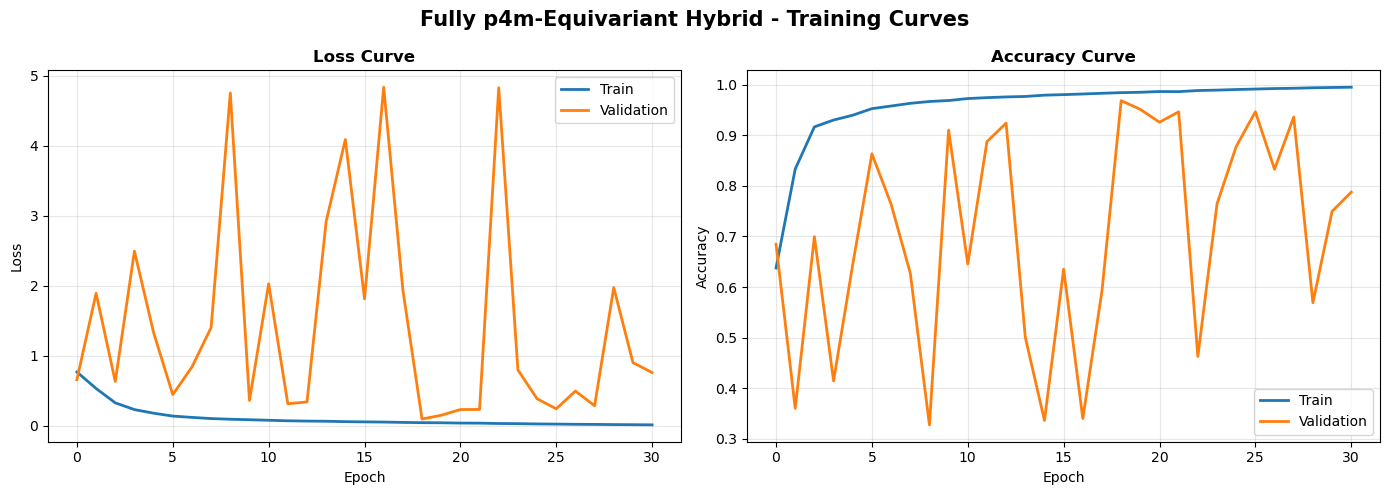

Testing: 100%|██████████| 235/235 [00:17<00:00, 13.80it/s]



Test Accuracy: 96.81%
Test ROC-AUC (macro OVR): 0.9964

              precision    recall  f1-score   support

       axion       0.97      0.95      0.96      5000
         cdm       0.95      0.95      0.95      5000
      no_sub       0.98      1.00      0.99      5000

    accuracy                           0.97     15000
   macro avg       0.97      0.97      0.97     15000
weighted avg       0.97      0.97      0.97     15000



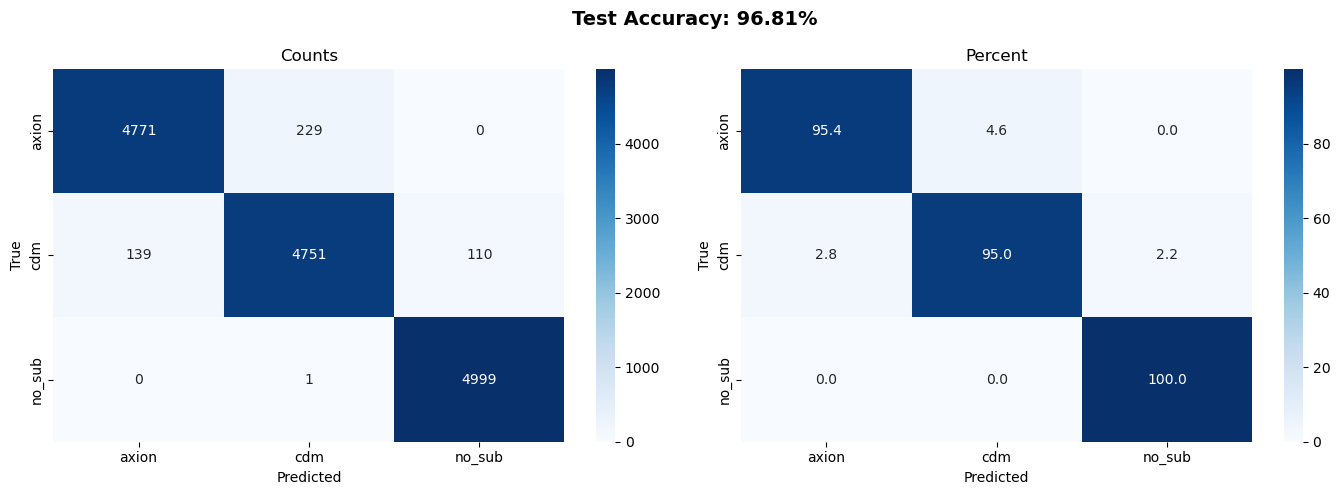

array([[4771,  229,    0],
       [ 139, 4751,  110],
       [   0,    1, 4999]])

In [15]:
plot_training_history(history)

test_acc, test_preds, test_labels, test_probs, test_roc_auc = evaluate_model(
    model, test_loader, device=device
)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")
print(f"Test ROC-AUC (macro OVR): {test_roc_auc:.4f}\n")
print(classification_report(test_labels, test_preds, target_names=class_names))

plot_confusion_matrix(test_labels, test_preds, class_names, test_acc)
